In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(5)

# Варіант 5 — Дніпро
city = "Дніпро"
base_temp = 10.0
amplitude = 14
base_consumption = 2900
k = 42
noise_sd = 50

months = np.arange(1, 13)

temp = (
    base_temp
    + amplitude * np.cos((months - 7) / 12 * 2 * np.pi)
)

temp = np.round(
    temp + np.random.normal(0, 0.5, size=12),
    1
)

consumption = (
    base_consumption
    - k * (temp - base_temp)
    + np.random.normal(0, noise_sd, size=12)
)

consumption = np.round(consumption, 0)

city_data = pd.DataFrame({
    "місяць": months,
    "температура": temp,
    "споживання_МВтгод": consumption
})

city_data

,місяць,температура,споживання_МВтгод
0,1,-3.8,3462.0
1,2,-2.3,3447.0
2,3,4.2,3060.0
3,4,9.9,2869.0
4,5,17.1,2659.0
5,6,22.9,2451.0
6,7,23.5,2257.0
7,8,21.8,2437.0
8,9,17.1,2553.0
9,10,9.8,2866.0


1. Детермінована чи стохастична?

Модель є стохастичною.

Її середня частина задається детермінованою лінійною
формулою:

споживання = a + b × температура.

Для фіксованої температури ця формула дає одне
конкретне прогнозоване значення.

Проте фактичні спостереження містять випадковий шум.
У коді генерації він задається через:

np.random.normal(0, noise_sd, size=12).

Тому повна модель складається з детермінованої
середньої частини та випадкового відхилення.
Через це модель у цілому є стохастичною.


2. Балансова, оптимізаційна, імітаційна чи жодна
з цих трьох?

Модель не є жодною з цих трьох.

Вона не є балансовою, оскільки в ній немає рівняння
збереження ресурсів або рівності типу
"надходження = витрати".

Вона не є оптимізаційною, оскільки ми не шукаємо
найкраще рішення за певним критерієм і не мінімізуємо
чи максимізуємо цільову функцію для прийняття рішення.

Вона також не є імітаційною, оскільки не відтворює
покрокову поведінку складної системи в часі.

Це описова та прогнозна статистична модель, яка
описує залежність споживання електроенергії
від температури.


3. Статична чи динамічна?

Модель є статичною.

Передбачене споживання конкретного місяця залежить
лише від температури цього самого місяця.

Споживання попереднього місяця не використовується
для визначення наступного.

Те, що дані містять 12 послідовних місяців, саме
по собі не робить модель динамічною.

Отже, модель є:

— стохастичною;
— статичною;
— описовою/прогнозною статистичною моделлю,
  яка не є балансовою, оптимізаційною чи імітаційною.

In [2]:
b, a = np.polyfit(
    city_data["температура"],
    city_data["споживання_МВтгод"],
    1
)

print(f"a = {a:.2f}")
print(f"b = {b:.2f}")

print(
    f"споживання ≈ {a:.1f} + "
    f"({b:.1f}) × температура"
)

city_data["передбачення"] = (
    a + b * city_data["температура"]
)

a = 3293.56
b = -40.65
споживання ≈ 3293.6 + (-40.7) × температура


Для Дніпра отримано лінійну модель:

споживання ≈ 3293.6 - 40.7 × температура.

Коефіцієнт b ≈ -40.7 є від'ємним.

Це означає, що при збільшенні середньомісячної
температури на 1 °C прогнозоване споживання
електроенергії в середньому зменшується приблизно
на 40.7 МВт·год.

Від'ємний знак узгоджується зі змістом задачі:
за нижчих температур більше електроенергії
витрачається на опалення, а за вищих температур
потреба в опаленні зменшується.

Фактичний коефіцієнт також близький до параметра
k = 42, використаного при генерації даних.

In [3]:
city_data["залишок"] = (
    city_data["споживання_МВтгод"]
    - city_data["передбачення"]
)

result_table = city_data[
    [
        "місяць",
        "температура",
        "споживання_МВтгод",
        "передбачення",
        "залишок"
    ]
].copy()

result_table["передбачення"] = (
    result_table["передбачення"].round(1)
)

result_table["залишок"] = (
    result_table["залишок"].round(1)
)

result_table

,місяць,температура,споживання_МВтгод,передбачення,залишок
0,1,-3.8,3462.0,3448.0,14.0
1,2,-2.3,3447.0,3387.1,59.9
2,3,4.2,3060.0,3122.8,-62.8
3,4,9.9,2869.0,2891.1,-22.1
4,5,17.1,2659.0,2598.4,60.6
5,6,22.9,2451.0,2362.6,88.4
6,7,23.5,2257.0,2338.2,-81.2
7,8,21.8,2437.0,2407.3,29.7
8,9,17.1,2553.0,2598.4,-45.4
9,10,9.8,2866.0,2895.2,-29.2


In [4]:
residuals = (
    city_data["споживання_МВтгод"]
    - city_data["передбачення"]
)

ss_res = (residuals ** 2).sum()

ss_tot = (
    (
        city_data["споживання_МВтгод"]
        - city_data["споживання_МВтгод"].mean()
    ) ** 2
).sum()

r_squared = 1 - ss_res / ss_tot

print("SS_res =", ss_res)
print("SS_tot =", ss_tot)
print("R² =", r_squared)

SS_res = 30559.33372435346
SS_tot = 1965470.6666666667
R² = 0.984451900380594


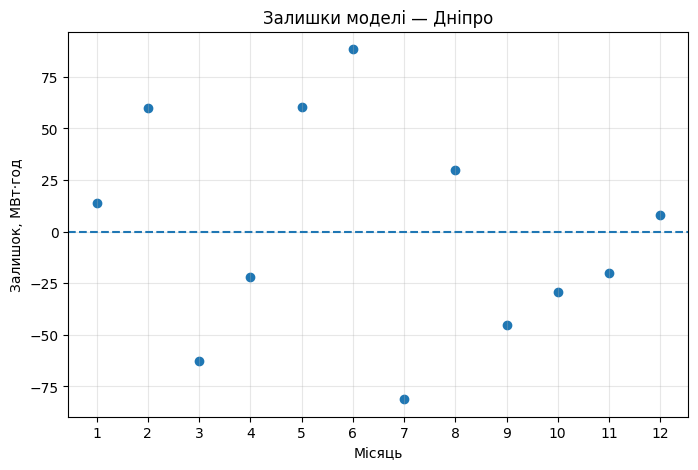

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    city_data["місяць"],
    city_data["залишок"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Місяць")
plt.ylabel("Залишок, МВт·год")
plt.title("Залишки моделі — Дніпро")

plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.show()

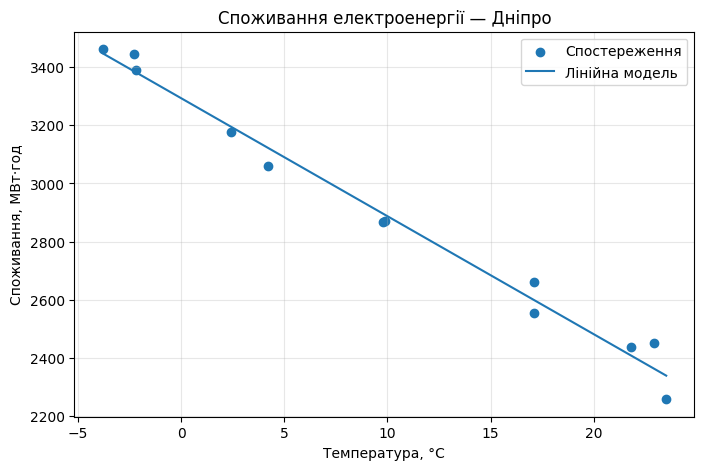

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    city_data["температура"],
    city_data["споживання_МВтгод"],
    label="Спостереження"
)

order = np.argsort(city_data["температура"])

plt.plot(
    city_data["температура"].iloc[order],
    city_data["передбачення"].iloc[order],
    label="Лінійна модель"
)

plt.xlabel("Температура, °C")
plt.ylabel("Споживання, МВт·год")
plt.title("Споживання електроенергії — Дніпро")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Коефіцієнт детермінації становить:

R² ≈ 0.9845.

Отже, приблизно 98.45% варіації місячного споживання
електроенергії в цьому наборі пояснюється лінійним
зв'язком із температурою.

Це дуже високе значення R².

Аналіз залишків також не показує очевидного
систематичного тренду. Залишки мають як додатні,
так і від'ємні значення та в цілому коливаються
навколо нуля.

Наприклад, у 6-му місяці залишок становить приблизно
+88.4 МВт·год, а в 7-му — приблизно -81.2 МВт·год.
Тобто присутній випадковий розкид, але немає ситуації,
коли модель систематично завищує або занижує
споживання протягом усієї зими чи літа.

Поєднання високого R² ≈ 0.9845 та відсутності
очевидної систематичної структури в залишках
свідчить, що проста лінійна модель є адекватною
для опису цих даних у спостереженому діапазоні
температур.

Водночас високе R² саме по собі не доводить,
що модель є правильною для будь-яких умов або
для екстраполяції далеко за межі наявних температур.

In [7]:
temp_january = city_data.loc[
    city_data["місяць"] == 1,
    "температура"
].iloc[0]

manual_prediction = a + b * temp_january

code_prediction = city_data.loc[
    city_data["місяць"] == 1,
    "передбачення"
].iloc[0]

print("Температура січня:", temp_january)
print("Ручний розрахунок:", manual_prediction)
print("Значення в DataFrame:", code_prediction)

print(
    "Збігаються:",
    np.isclose(
        manual_prediction,
        code_prediction
    )
)

Температура січня: -3.8
Ручний розрахунок: 3448.046347282886
Значення в DataFrame: 3448.046347282886
Збігаються: True


Верифікація моєї моделі означає перевірку того,
чи правильно код реалізує задану математичну формулу.

Наприклад, для січня температура становить -3.8 °C.

Підставляємо її вручну в отриману модель:

споживання =
3293.56 - 40.65 × (-3.8)
≈ 3448.05 МВт·год.

Значення, яке автоматично обчислив код у стовпці
"передбачення", також становить приблизно
3448.05 МВт·год.

Результати збігаються.

Отже, ця перевірка підтверджує, що формула
передбачення реалізована в коді правильно.

Це перевірка реалізації моделі, а не перевірка того,
наскільки добре сама модель описує реальність.

Валідація означає перевірку того, наскільки побудована
модель відповідає реальним даним і чи здатна вона
правильно працювати на нових спостереженнях.

У цій роботі модель підібрана за 12 місяцями того
самого року, тому оцінка R² і залишків на цих же
12 спостереженнях є корисною перевіркою адекватності,
але не повністю незалежною валідацією.

Для чеснішої валідації потрібно отримати нові дані,
які не використовувалися для підбору коефіцієнтів
a та b.

Наприклад, можна використати температури та фактичне
споживання Дніпра за наступний рік.

Після цього модель, побудовану на першому році,
слід застосувати до другого року і порівняти її
прогнози з фактичним споживанням.

Якщо помилки залишаться невеликими і не матимуть
систематичної структури, це буде сильнішим
підтвердженням валідності моделі.

Для мого варіанта проста лінійна модель виявилася
достатньо адекватною для поставленої задачі.

Вона має R² ≈ 0.9845, тобто пояснює приблизно
98.45% варіації споживання.

Крім того, залишки не демонструють очевидного
систематичного тренду і в цілому розкидані
навколо нуля.

Тому додавання складнішої нелінійної залежності
або великої кількості додаткових параметрів
для цього набору даних не є необхідним.

У моделюванні існує компроміс між точністю
та простотою.

Складніша модель може трохи краще підлаштуватися
під 12 наявних спостережень, але це не обов'язково
означатиме кращу роботу на нових даних. Надмірне
ускладнення також може призвести до перенавчання.

Тому для прогнозування місячного споживання в межах
спостереженого діапазону температур доцільно залишити
просту лінійну модель.

Як можливе майбутнє вдосконалення, якщо нові дані
покажуть систематичні помилки, можна додати інші
важливі фактори, наприклад тривалість опалювального
періоду або інші погодні характеристики.

1. Чим відрізняються верифікація та валідація
для нашої моделі?

Верифікація перевіряє, чи правильно реалізовано
математичну модель у коді.

У нашій роботі ми вручну обчислили прогноз для
січня за формулою a + b × температура та порівняли
його зі значенням, отриманим програмою. Значення
збіглися, тому реалізація формули працює правильно.

Валідація відповідає на інше питання: чи достатньо
добре модель описує реальність і працює на нових даних.

Для повноцінної валідації бажано використати,
наприклад, дані Дніпра за наступний рік, які не
використовувалися при оцінюванні a та b.


2. За якими незалежними ознаками класифікується
наша модель?

Модель є стохастичною, оскільки складається
з детермінованої середньої залежності та випадкового
залишку.

Вона є статичною, оскільки прогноз кожного місяця
залежить від температури цього місяця, а не від
попереднього стану системи.

За призначенням це описова/прогнозна статистична
модель. Вона не є балансовою, оптимізаційною
або імітаційною.

Ці характеристики не суперечать одна одній,
оскільки описують різні властивості моделі.


3. Що показує R² і чи доводить високе R²
правильність моделі?

Для нашої моделі R² ≈ 0.9845.

Це означає, що приблизно 98.45% варіації
споживання електроенергії в наявній вибірці
пояснюється лінійним зв'язком із температурою.

Високе R² саме по собі не доводить, що модель
повністю правильна.

Потрібно також аналізувати залишки та перевіряти
модель на нових даних.

Також високе R² не гарантує правильність
екстраполяції далеко за межі спостереженого
діапазону температур.


4. Чому структура залишків важливіша, ніж лише
їхня сумарна величина?

Сумарна величина помилок показує загальний рівень
неточності, але може приховувати систематичну
проблему моделі.

Наприклад, модель може постійно недооцінювати
споживання взимку і переоцінювати його влітку.
Навіть при відносно невеликих помилках це означало б,
що математична форма моделі не враховує важливу
закономірність.

Якщо ж залишки випадково розташовані навколо нуля
без видимого тренду, це більше відповідає ситуації,
коли модель описує основну закономірність, а залишкові
відхилення спричинені випадковим шумом.

У нашому випадку явного систематичного тренду
залишків не спостерігається, що разом із високим
R² підтримує висновок про достатню адекватність
лінійної моделі для цих даних.